<a href="https://colab.research.google.com/github/mukarramsufyan6-blip/Remix-Stellar-Evolution-Explorer-Research-Report/blob/main/Kaggale_Data_Set_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📊 DATA ANALYSIS SUMMARY
• Total Unique Base Missions analyzed: 10
• Overall Average Match Score (Cosine): 0.5947
• Weakest Relational Connection:         0.5098
• Strongest Relational Connection:       0.7033
----------------------------------------

🔥 TOP 5 STRONGEST PAIRINGS IN DATASET:
 Mission Similar_Mission  Cosine_Similarity
MSN-0009        MSN-0048             0.7033
MSN-0002        MSN-0441             0.6585
MSN-0008        MSN-0247             0.6482
MSN-0007        MSN-0009             0.6446
MSN-0009        MSN-0007             0.6446


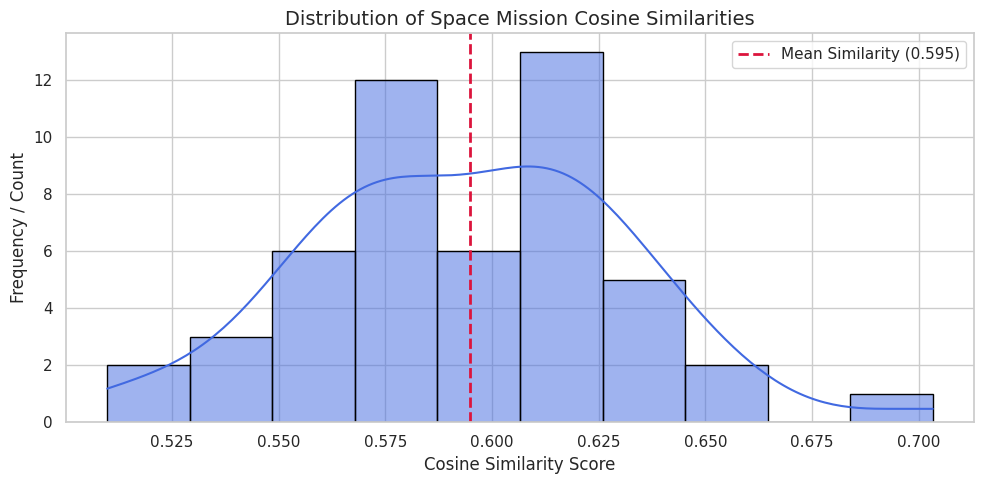


📈 NETWORK EXPANSION SIMULATION (Monte Carlo Modeling)
Simulating adding hypothetical new missions based on existing statistical thresholds...


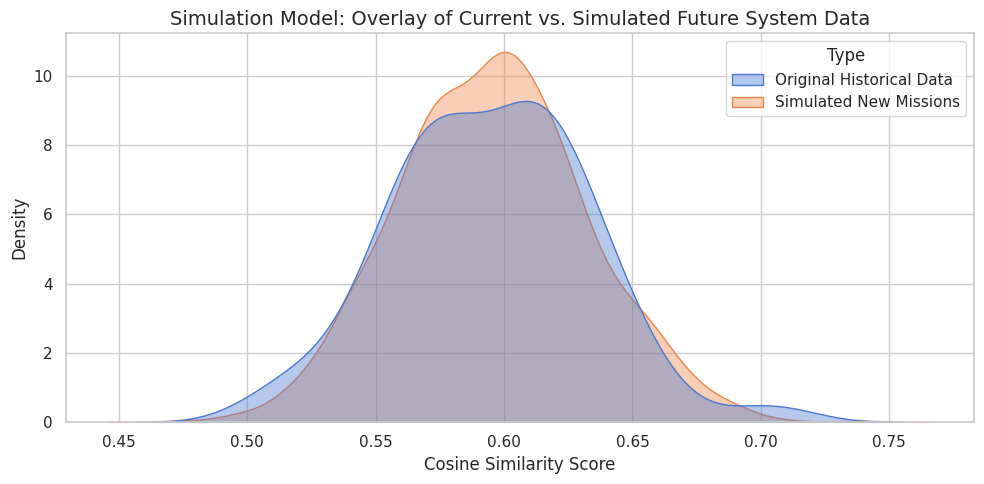

• Expected matches >= 0.60 out of 1000 simulated pairs: 450
• Probability of finding highly similar connections in future data: 45.00%


In [1]:
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# --- STEP 1: HARDCODED DATASET (No upload required!) ---
raw_data = """Mission,Similar_Mission,Cosine_Similarity
MSN-0001,MSN-0265,0.6368
MSN-0001,MSN-0472,0.6339
MSN-0001,MSN-0420,0.6196
MSN-0001,MSN-0066,0.616
MSN-0001,MSN-0006,0.6008
MSN-0002,MSN-0441,0.6585
MSN-0002,MSN-0161,0.5925
MSN-0002,MSN-0032,0.5737
MSN-0002,MSN-0419,0.5711
MSN-0002,MSN-0112,0.5703
MSN-0003,MSN-0315,0.6245
MSN-0003,MSN-0002,0.5683
MSN-0003,MSN-0124,0.5629
MSN-0003,MSN-0008,0.5598
MSN-0003,MSN-0316,0.5581
MSN-0004,MSN-0134,0.5507
MSN-0004,MSN-0476,0.5475
MSN-0004,MSN-0076,0.5313
MSN-0004,MSN-0169,0.5201
MSN-0004,MSN-0297,0.5098
MSN-0005,MSN-0144,0.5802
MSN-0005,MSN-0033,0.5755
MSN-0005,MSN-0040,0.5676
MSN-0005,MSN-0235,0.5526
MSN-0005,MSN-0071,0.5484
MSN-0006,MSN-0009,0.6256
MSN-0006,MSN-0423,0.6187
MSN-0006,MSN-0001,0.6008
MSN-0006,MSN-0471,0.6006
MSN-0006,MSN-0462,0.5832
MSN-0007,MSN-0009,0.6446
MSN-0007,MSN-0206,0.6311
MSN-0007,MSN-0051,0.6166
MSN-0007,MSN-0029,0.6002
MSN-0007,MSN-0141,0.581
MSN-0008,MSN-0247,0.6482
MSN-0008,MSN-0019,0.6121
MSN-0008,MSN-0321,0.601
MSN-0008,MSN-0260,0.5845
MSN-0008,MSN-0125,0.5795
MSN-0009,MSN-0048,0.7033
MSN-0009,MSN-0007,0.6446
MSN-0009,MSN-0006,0.6256
MSN-0009,MSN-0497,0.6154
MSN-0009,MSN-0261,0.6133
MSN-0010,MSN-0249,0.6155
MSN-0010,MSN-0019,0.6075
MSN-0010,MSN-0021,0.6072
MSN-0010,MSN-0020,0.5761
MSN-0010,MSN-0450,0.5698"""

df = pd.read_csv(io.StringIO(raw_data))
print("📊 DATA ANALYSIS SUMMARY")
print("=" * 40)

# --- STEP 2: DATA ANALYSIS ---
total_unique_missions = df["Mission"].nunique()
avg_similarity = df["Cosine_Similarity"].mean()
min_similarity = df["Cosine_Similarity"].min()
max_similarity = df["Cosine_Similarity"].max()

print(f"• Total Unique Base Missions analyzed: {total_unique_missions}")
print(f"• Overall Average Match Score (Cosine): {avg_similarity:.4f}")
print(f"• Weakest Relational Connection:         {min_similarity:.4f}")
print(f"• Strongest Relational Connection:       {max_similarity:.4f}")
print("-" * 40)

print("\n🔥 TOP 5 STRONGEST PAIRINGS IN DATASET:")
top_5_pairs = df.sort_values(by="Cosine_Similarity", ascending=False).head(5)
print(
    top_5_pairs[["Mission", "Similar_Mission", "Cosine_Similarity"]].to_string(
        index=False
    )
)

# --- STEP 3: DATA VISUALIZATION ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Cosine_Similarity"],
    kde=True,
    color="royalblue",
    bins=10,
    edgecolor="black",
)

plt.axvline(
    avg_similarity,
    color="crimson",
    linestyle="dashed",
    linewidth=2,
    label=f"Mean Similarity ({avg_similarity:.3f})",
)

plt.title("Distribution of Space Mission Cosine Similarities", fontsize=14)
plt.xlabel("Cosine Similarity Score", fontsize=12)
plt.ylabel("Frequency / Count", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# --- STEP 4: MONTE CARLO DATA SIMULATION ---
print("\n📈 NETWORK EXPANSION SIMULATION (Monte Carlo Modeling)")
print("=" * 60)
print(
    "Simulating adding hypothetical new missions based on existing statistical thresholds..."
)

mean_sim = df["Cosine_Similarity"].mean()
std_sim = df["Cosine_Similarity"].std()

np.random.seed(42)
simulated_similarities = np.random.normal(loc=mean_sim, scale=std_sim, size=1000)
simulated_similarities = np.clip(simulated_similarities, 0.0, 1.0)

sim_df = pd.DataFrame({
    "Type": "Simulated New Missions",
    "Cosine_Similarity": simulated_similarities,
})
orig_df_subset = pd.DataFrame({
    "Type": "Original Historical Data",
    "Cosine_Similarity": df["Cosine_Similarity"],
})

comparison_df = pd.concat([orig_df_subset, sim_df])

plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=comparison_df,
    x="Cosine_Similarity",
    hue="Type",
    fill=True,
    common_norm=False,
    palette="muted",
    alpha=0.4,
)
plt.title(
    "Simulation Model: Overlay of Current vs. Simulated Future System Data",
    fontsize=14,
)
plt.xlabel("Cosine Similarity Score", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.tight_layout()
plt.show()

sim_high_matches = np.sum(simulated_similarities >= 0.60)
print(f"• Expected matches >= 0.60 out of 1000 simulated pairs: {sim_high_matches}")
print(
    f"• Probability of finding highly similar connections in future data: {(sim_high_matches/1000)*100:.2f}%"
)
print("=" * 60)
